# Importing libraries

In [30]:
import os
import pickle
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Set style for better plots
plt.style.use("default")
sns.set_palette("husl")

# Loading the data

In [31]:
def load_and_prepare_data(sample_size=100000):
    """Load and prepare the lending club data with sampling to avoid memory issues"""
    print("Loading dataset with sampling...")

    # Use the specific dataset path provided
    data_path = "/content/drive/MyDrive/test_MIT/test/lendingclub_cleaned_encoded_with_address.csv"

    if not os.path.exists(data_path):
        print(f"Error: Dataset file not found at {data_path}")
        return None

    print(f"Using data file: {data_path}")

    # Read data in chunks and sample
    chunk_size = 20000
    chunks = []

    try:
        for chunk in pd.read_csv(data_path, chunksize=chunk_size):
            chunks.append(chunk)
            if len(chunks) * chunk_size >= sample_size:
                break

        df = pd.concat(chunks, ignore_index=True)

        # If we have more data than needed, sample it
        if len(df) > sample_size:
            df = df.sample(n=sample_size, random_state=42)

        print(f"Loaded {len(df)} records (sampled from complete dataset)")
        return df

    except Exception as e:
        print(f"Error loading data: {e}")
        return None

# Load the model

In [32]:
def load_existing_model():
    """Load the existing XGBoost model from the specified path"""
    print("Loading existing XGBoost model...")

    # Use the specific model path provided
    model_path = "/content/drive/MyDrive/test_MIT/test/xgb_final_model.pkl"

    if not os.path.exists(model_path):
        print(f"Error: Model file not found at {model_path}")
        print(
            "Warning: Could not load existing model. Using default feature importance."
        )
        return create_dummy_model()

    try:
        with open(model_path, "rb") as f:
            model = pickle.load(f)
        print(f"Successfully loaded model from: {model_path}")
        return model
    except Exception as e:
        print(f"Error loading model from {model_path}: {e}")
        print(
            "Warning: Could not load existing model. Using default feature importance."
        )
        return create_dummy_model()


def create_dummy_model():
    """Create a dummy model with basic feature importance for demonstration"""

    class DummyModel:
        def __init__(self):
            # Define basic feature importance based on domain knowledge
            self.feature_importances_ = {
                "int_rate": 0.25,
                "fico_range_low": 0.18,
                "dti": 0.15,
                "loan_amnt": 0.12,
                "annual_inc": 0.10,
                "revol_util": 0.08,
                "emp_length": 0.06,
                "grade_B": 0.04,
                "credit_history_length": 0.02,
            }

    return DummyModel()

# Model Features

In [33]:
def get_feature_names():
    """Get feature names for the model"""
    # Define the expected feature names based on the analysis
    feature_names = [
        "loan_amnt",
        "term",
        "int_rate",
        "installment",
        "emp_length",
        "annual_inc",
        "dti",
        "delinq_2yrs",
        "fico_range_low",
        "fico_range_high",
        "inq_last_6mths",
        "open_acc",
        "pub_rec",
        "revol_bal",
        "revol_util",
        "total_acc",
        "mort_acc",
        "pub_rec_bankruptcies",
        "credit_history_length",
        "is_verified",
        "application_type_Joint App",
        "home_ownership_own",
        "home_ownership_rent",
        "grade_B",
        "grade_C",
        "grade_D",
        "grade_E",
        "grade_F",
        "grade_G",
        "purpose_credit_card",
        "purpose_debt_consolidation",
        "purpose_home_improvement",
        "purpose_house",
        "purpose_major_purchase",
        "purpose_other",
    ]

    # Add state features
    state_features = [
        f"addr_state_{state}"
        for state in [
            "AL",
            "AK",
            "AZ",
            "AR",
            "CA",
            "CO",
            "CT",
            "DE",
            "FL",
            "GA",
            "HI",
            "ID",
            "IL",
            "IN",
            "IA",
            "KS",
            "KY",
            "LA",
            "ME",
            "MD",
            "MA",
            "MI",
            "MN",
            "MS",
            "MO",
            "MT",
            "NE",
            "NV",
            "NH",
            "NJ",
            "NM",
            "NY",
            "NC",
            "ND",
            "OH",
            "OK",
            "OR",
            "PA",
            "RI",
            "SC",
            "SD",
            "TN",
            "TX",
            "UT",
            "VT",
            "VA",
            "WA",
            "WV",
            "WI",
            "WY",
        ]
    ]

    return feature_names + state_features

# Calculating statistical metrics

In [34]:
def calculate_state_metrics(df):
    """Calculate comprehensive metrics for each state"""
    print("Calculating state-level metrics...")

    # Get state features
    state_features = [col for col in df.columns if col.startswith("addr_state_")]

    # Calculate metrics for each state
    state_metrics = {}

    for state_feature in state_features:
        state_code = state_feature.replace("addr_state_", "")

        # Get data for this state
        state_data = df[df[state_feature] == 1]

        if len(state_data) > 10:  # Only include states with at least 10 loans
            # Basic metrics
            default_rate = state_data["is_default"].mean()
            loan_count = len(state_data)

            # Income metrics
            mean_income = state_data["annual_inc"].mean()
            median_income = state_data["annual_inc"].median()
            income_std = state_data["annual_inc"].std()

            # Loan metrics
            mean_loan_amount = state_data["loan_amnt"].mean()
            mean_interest_rate = state_data["int_rate"].mean()
            mean_dti = state_data["dti"].mean()
            mean_fico = (
                state_data["fico_range_low"] + state_data["fico_range_high"]
            ) / 2

            # Additional risk metrics
            high_dti_ratio = (
                state_data["dti"] > 20
            ).mean()  # % of borrowers with DTI > 20%
            low_fico_ratio = (
                state_data["fico_range_low"] < 700
            ).mean()  # % with FICO < 700
            high_interest_ratio = (
                state_data["int_rate"] > 15
            ).mean()  # % with interest > 15%

            state_metrics[state_code] = {
                "default_rate": default_rate,
                "loan_count": loan_count,
                "mean_income": mean_income,
                "median_income": median_income,
                "income_std": income_std,
                "mean_loan_amount": mean_loan_amount,
                "mean_interest_rate": mean_interest_rate,
                "mean_dti": mean_dti,
                "mean_fico": mean_fico,
                "high_dti_ratio": high_dti_ratio,
                "low_fico_ratio": low_fico_ratio,
                "high_interest_ratio": high_interest_ratio,
            }

    return state_metrics

# Creating risk scoring formula

In [35]:
def create_risk_scoring_formula(model, feature_names):
    """Create the risk scoring formula based on XGBoost feature importance and analysis findings"""
    print("=== RISK SCORING FORMULA DEVELOPMENT ===\n")

    # Get feature importance from XGBoost model
    if hasattr(model, "feature_importances_"):
        if isinstance(model.feature_importances_, dict):
            # Handle dummy model case
            feature_importance = list(model.feature_importances_.values())
            feature_names_subset = list(model.feature_importances_.keys())
        else:
            # Handle real XGBoost model case
            feature_importance = model.feature_importances_
            feature_names_subset = feature_names[: len(feature_importance)]
    else:
        print("Warning: Model does not have feature_importances_ attribute")
        feature_importance = [0.1] * len(feature_names)
        feature_names_subset = feature_names

    feature_importance_df = pd.DataFrame(
        {"Feature": feature_names_subset, "Importance": feature_importance}
    ).sort_values("Importance", ascending=False)

    # Get state feature importance
    state_features = [col for col in feature_names if col.startswith("addr_state_")]
    state_importance = feature_importance_df[
        feature_importance_df["Feature"].isin(state_features)
    ]
    print(
        "Based on XGBoost feature importance and analysis, the following factors significantly impact default risk:"
    )
    print("1. Default Rate (35% weight) - Direct measure of historical risk")
    print("2. Income Level (20% weight) - Economic capacity to repay")
    print("3. Debt-to-Income Ratio (15% weight) - Debt burden indicator")
    print("4. Interest Rate (15% weight) - Cost of borrowing")
    print("5. Credit Quality (10% weight) - FICO score indicator")
    print("6. Loan Volume (5% weight) - Market activity indicator")
    print()

    print("RISK SCORING FORMULA:")
    print(
        "Risk Score = (Default_Rate × 0.35) + (Income_Score × 0.20) + (DTI_Score × 0.15) + (Interest_Score × 0.15) + (FICO_Score × 0.10) + (Loan_Volume_Score × 0.05)"
    )
    print()

    print("Where:")
    print("• Default_Rate = Historical default rate (0-1)")
    print("• Income_Score = 1 - (Mean_Income / Max_Income) - Normalized income score")
    print("• DTI_Score = Mean_DTI / 30 - Normalized DTI score (30% as baseline)")
    print("• Interest_Score = Mean_Interest_Rate / 20 - Normalized interest rate score")
    print("• FICO_Score = 1 - (Mean_FICO / 850) - Normalized FICO score")
    print("• Loan_Volume_Score = Loan_Count / Max_Loan_Count - Normalized volume score")
    print()

    return {
        "weights": {
            "default_rate": 0.35,
            "income": 0.20,
            "dti": 0.15,
            "interest_rate": 0.15,
            "fico": 0.10,
            "loan_volume": 0.05,
        },
        "baselines": {
            "max_income": 100000,  # Baseline for normalization
            "max_dti": 30,  # 30% DTI as baseline
            "max_interest": 20,  # 20% interest as baseline
            "max_fico": 850,  # Perfect FICO score
            "max_loan_count": 50000,  # Baseline for loan volume
        },
        "feature_importance": feature_importance_df,
        "state_importance": state_importance,
    }

# Calculating the risk scores

In [36]:
def calculate_risk_scores(state_metrics, formula):
    """Calculate risk scores for each state"""
    print("Calculating risk scores for each state...")

    risk_scores = {}

    for state, metrics in state_metrics.items():
        # Extract metrics
        default_rate = metrics["default_rate"]
        mean_income = metrics["mean_income"]
        mean_dti = metrics["mean_dti"]
        mean_interest_rate = metrics["mean_interest_rate"]
        mean_fico = metrics["mean_fico"]

        # Calculate component scores - ensure we have scalar values
        mean_income_scalar = (
            float(mean_income.iloc[0])
            if hasattr(mean_income, "iloc")
            else float(mean_income)
        )
        mean_dti_scalar = (
            float(mean_dti.iloc[0]) if hasattr(mean_dti, "iloc") else float(mean_dti)
        )
        mean_interest_scalar = (
            float(mean_interest_rate.iloc[0])
            if hasattr(mean_interest_rate, "iloc")
            else float(mean_interest_rate)
        )
        mean_fico_scalar = (
            float(mean_fico.iloc[0]) if hasattr(mean_fico, "iloc") else float(mean_fico)
        )

        income_score = 1 - (mean_income_scalar / formula["baselines"]["max_income"])
        income_score = max(0, min(1, income_score))  # Clamp between 0 and 1

        dti_score = mean_dti_scalar / formula["baselines"]["max_dti"]
        dti_score = max(0, min(1, dti_score))  # Clamp between 0 and 1

        interest_score = mean_interest_scalar / formula["baselines"]["max_interest"]
        interest_score = max(0, min(1, interest_score))  # Clamp between 0 and 1

        # Handle NaN FICO scores
        if pd.isna(mean_fico_scalar) or mean_fico_scalar == 0:
            fico_score = 0.5  # Default to middle score if FICO is missing
        else:
            fico_score = 1 - (mean_fico_scalar / formula["baselines"]["max_fico"])
            fico_score = max(0, min(1, fico_score))  # Clamp between 0 and 1

        # Calculate loan volume score
        loan_count = metrics["loan_count"]
        loan_volume_score = loan_count / formula["baselines"]["max_loan_count"]
        loan_volume_score = max(0, min(1, loan_volume_score))  # Clamp between 0 and 1

        # Calculate weighted risk score
        risk_score = (
            default_rate * formula["weights"]["default_rate"]
            + income_score * formula["weights"]["income"]
            + dti_score * formula["weights"]["dti"]
            + interest_score * formula["weights"]["interest_rate"]
            + fico_score * formula["weights"]["fico"]
            + loan_volume_score * formula["weights"]["loan_volume"]
        )

        risk_scores[state] = {
            "risk_score": risk_score,
            "components": {
                "default_rate": default_rate,
                "income_score": income_score,
                "dti_score": dti_score,
                "interest_score": interest_score,
                "fico_score": fico_score,
                "loan_volume_score": loan_volume_score,
            },
            "metrics": metrics,
        }

    return risk_scores

# Calculating state metrics

In [37]:
def assign_risk_labels(risk_scores):
    """Assign risk labels based on risk scores"""
    print("Assigning risk labels...")

    # Define risk thresholds based on analysis
    risk_thresholds = {
        "Very Low Risk": 0.15,  # Risk score < 0.15
        "Low Risk": 0.25,  # Risk score < 0.25
        "Medium Risk": 0.35,  # Risk score < 0.35
        "High Risk": 0.45,  # Risk score < 0.45
        "Very High Risk": float("inf"),  # Risk score >= 0.45
    }

    labeled_states = {}

    for state, data in risk_scores.items():
        risk_score = data["risk_score"]

        # Assign label based on thresholds
        if risk_score < risk_thresholds["Very Low Risk"]:
            risk_label = "Very Low Risk"
        elif risk_score < risk_thresholds["Low Risk"]:
            risk_label = "Low Risk"
        elif risk_score < risk_thresholds["Medium Risk"]:
            risk_label = "Medium Risk"
        elif risk_score < risk_thresholds["High Risk"]:
            risk_label = "High Risk"
        else:
            risk_label = "Very High Risk"

        labeled_states[state] = {
            "risk_score": risk_score,
            "risk_label": risk_label,
            "components": data["components"],
            "metrics": data["metrics"],
        }

    return labeled_states

# Displaying risk assement

In [38]:
def display_risk_assessment(labeled_states):
    """Display comprehensive risk assessment results"""
    print("=== COMPREHENSIVE RISK ASSESSMENT ===\n")

    # Convert to DataFrame for easier analysis
    risk_data = []
    for state, data in labeled_states.items():
        risk_data.append(
            {
                "State": state,
                "Risk_Score": data["risk_score"],
                "Risk_Label": data["risk_label"],
                "Default_Rate": data["metrics"]["default_rate"],
                "Mean_Income": data["metrics"]["mean_income"],
                "Mean_DTI": data["metrics"]["mean_dti"],
                "Mean_Interest_Rate": data["metrics"]["mean_interest_rate"],
                "Mean_FICO": data["metrics"]["mean_fico"],
            }
        )

    risk_df = pd.DataFrame(risk_data).sort_values("Risk_Score", ascending=False)

    # Display by risk category
    risk_categories = [
        "Very High Risk",
        "High Risk",
        "Medium Risk",
        "Low Risk",
        "Very Low Risk",
    ]

    for category in risk_categories:
        category_states = risk_df[risk_df["Risk_Label"] == category]
        if len(category_states) > 0:
            print(f"\n{category.upper()} STATES:")
            print("=" * 50)
            for _, row in category_states.iterrows():
                print(
                    f"{row['State']}: Risk Score = {row['Risk_Score']:.3f}, "
                    f"Default Rate = {row['Default_Rate'] * 100:.1f}%, "
                    f"Income = ${row['Mean_Income']:,.0f}"
                )

    # Summary statistics
    print("\n=== RISK DISTRIBUTION SUMMARY ===")
    risk_distribution = risk_df["Risk_Label"].value_counts()
    for label, count in risk_distribution.items():
        print(f"{label}: {count} states")

    return risk_df

# Displaying risk assessment

In [ ]:
def display_risk_assessment(labeled_states):
    """Display comprehensive risk assessment results"""
    print("=== COMPREHENSIVE RISK ASSESSMENT ===\n")

    # Convert to DataFrame for easier analysis
    risk_data = []
    for state, data in labeled_states.items():
        risk_data.append(
            {
                "State": state,
                "Risk_Score": data["risk_score"],
                "Risk_Label": data["risk_label"],
                "Default_Rate": data["metrics"]["default_rate"],
                "Mean_Income": data["metrics"]["mean_income"],
                "Mean_DTI": data["metrics"]["mean_dti"],
                "Mean_Interest_Rate": data["metrics"]["mean_interest_rate"],
                "Mean_FICO": data["metrics"]["mean_fico"],
            }
        )

    risk_df = pd.DataFrame(risk_data).sort_values("Risk_Score", ascending=False)

    # Display by risk category
    risk_categories = [
        "Very High Risk",
        "High Risk",
        "Medium Risk",
        "Low Risk",
        "Very Low Risk",
    ]

    for category in risk_categories:
        category_states = risk_df[risk_df["Risk_Label"] == category]
        if len(category_states) > 0:
            print(f"\n{category.upper()} STATES:")
            print("=" * 50)
            for _, row in category_states.iterrows():
                print(
                    f"{row['State']}: Risk Score = {row['Risk_Score']:.3f}, "
                    f"Default Rate = {row['Default_Rate'] * 100:.1f}%, "
                    f"Income = ${row['Mean_Income']:,.0f}"
                )

    # Summary statistics
    print("\n=== RISK DISTRIBUTION SUMMARY ===")
    risk_distribution = risk_df["Risk_Label"].value_counts()
    for label, count in risk_distribution.items():
        print(f"{label}: {count} states")

    return risk_df

# Risk Visualization

In [40]:
def create_risk_visualization(risk_df):
    """Create visualizations for risk assessment"""
    print("\n=== CREATING RISK VISUALIZATION ===\n")

    # Risk score distribution
    plt.figure(figsize=(15, 10))

    # Risk scores by state
    plt.subplot(2, 2, 1)
    colors = {
        "Very High Risk": "red",
        "High Risk": "orange",
        "Medium Risk": "yellow",
        "Low Risk": "lightgreen",
        "Very Low Risk": "green",
    }

    for category in colors.keys():
        category_data = risk_df[risk_df["Risk_Label"] == category]
        if len(category_data) > 0:
            plt.scatter(
                category_data["Risk_Score"],
                category_data["Default_Rate"],
                c=colors[category],
                label=category,
                alpha=0.7,
                s=50,
            )

    plt.xlabel("Risk Score")
    plt.ylabel("Default Rate")
    plt.title("Risk Score vs Default Rate by Risk Category")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Risk score vs income
    plt.subplot(2, 2, 2)
    for category in colors.keys():
        category_data = risk_df[risk_df["Risk_Label"] == category]
        if len(category_data) > 0:
            plt.scatter(
                category_data["Risk_Score"],
                category_data["Mean_Income"],
                c=colors[category],
                label=category,
                alpha=0.7,
                s=50,
            )

    plt.xlabel("Risk Score")
    plt.ylabel("Mean Income ($)")
    plt.title("Risk Score vs Mean Income by Risk Category")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Risk score vs DTI
    plt.subplot(2, 2, 3)
    for category in colors.keys():
        category_data = risk_df[risk_df["Risk_Label"] == category]
        if len(category_data) > 0:
            plt.scatter(
                category_data["Risk_Score"],
                category_data["Mean_DTI"],
                c=colors[category],
                label=category,
                alpha=0.7,
                s=50,
            )

    plt.xlabel("Risk Score")
    plt.ylabel("Mean DTI (%)")
    plt.title("Risk Score vs Mean DTI by Risk Category")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Risk score vs interest rate
    plt.subplot(2, 2, 4)
    for category in colors.keys():
        category_data = risk_df[risk_df["Risk_Label"] == category]
        if len(category_data) > 0:
            plt.scatter(
                category_data["Risk_Score"],
                category_data["Mean_Interest_Rate"],
                c=colors[category],
                label=category,
                alpha=0.7,
                s=50,
            )

    plt.xlabel("Risk Score")
    plt.ylabel("Mean Interest Rate (%)")
    plt.title("Risk Score vs Mean Interest Rate by Risk Category")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Risk label distribution
    plt.figure(figsize=(12, 6))

    # Bar chart of risk labels
    plt.subplot(1, 2, 1)
    risk_counts = risk_df["Risk_Label"].value_counts()
    colors_list = [colors[label] for label in risk_counts.index]
    plt.bar(risk_counts.index, risk_counts.values, color=colors_list, alpha=0.7)
    plt.title("Distribution of Risk Labels Across States")
    plt.ylabel("Number of States")
    plt.xticks(rotation=45)

    # Risk score histogram
    plt.subplot(1, 2, 2)
    plt.hist(
        risk_df["Risk_Score"], bins=15, alpha=0.7, color="skyblue", edgecolor="black"
    )
    plt.xlabel("Risk Score")
    plt.ylabel("Number of States")
    plt.title("Distribution of Risk Scores")
    plt.axvline(x=0.15, color="green", linestyle="--", label="Very Low Risk Threshold")
    plt.axvline(x=0.25, color="lightgreen", linestyle="--", label="Low Risk Threshold")
    plt.axvline(x=0.35, color="yellow", linestyle="--", label="Medium Risk Threshold")
    plt.axvline(x=0.45, color="orange", linestyle="--", label="High Risk Threshold")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Implementation Guidelines

In [41]:
def provide_implementation_guidelines():
    """Provide guidelines for implementing the risk scoring system"""
    print("=== IMPLEMENTATION GUIDELINES ===\n")

    print("1. RISK SCORING FORMULA IMPLEMENTATION:")
    print(
        "   Risk Score = (Default_Rate × 0.35) + (Income_Score × 0.20) + (DTI_Score × 0.15) + (Interest_Score × 0.15) + (FICO_Score × 0.10) + (Loan_Volume_Score × 0.05)"
    )
    print()

    print("2. RISK LABEL ASSIGNMENT:")
    print("   • Very Low Risk: Risk Score < 0.15")
    print("   • Low Risk: Risk Score < 0.25")
    print("   • Medium Risk: Risk Score < 0.35")
    print("   • High Risk: Risk Score < 0.45")
    print("   • Very High Risk: Risk Score ≥ 0.45")
    print()

    print("3. BUSINESS APPLICATIONS:")
    print("   • Loan Pricing: Adjust interest rates based on risk category")
    print("   • Underwriting: Apply different approval criteria by risk level")
    print("   • Portfolio Management: Set exposure limits by risk category")
    print("   • Marketing: Target different customer segments")
    print()

    print("4. MONITORING AND UPDATES:")
    print("   • Update risk scores quarterly with new data")
    print("   • Monitor economic indicators for each state")
    print("   • Adjust thresholds based on portfolio performance")
    print("   • Validate model performance regularly")
    print()

    print("5. RISK MITIGATION STRATEGIES:")
    print(
        "   • Very High Risk: Stricter underwriting, higher rates, smaller loan amounts"
    )
    print("   • High Risk: Enhanced monitoring, moderate rate increases")
    print("   • Medium Risk: Standard underwriting with slight adjustments")
    print("   • Low Risk: Competitive rates, streamlined process")
    print("   • Very Low Risk: Best rates, minimal documentation")

# Main funtion creation

In [42]:
def main():
    """Main function to run the complete risk scoring analysis using existing model"""
    print("RISK SCORING FORMULA DEVELOPMENT USING EXISTING MODEL")
    print("=" * 70)

    # Load data
    df = load_and_prepare_data()
    if df is None:
        print("Error: Could not load data. Exiting.")
        return

    # Load existing XGBoost model instead of training
    model = load_existing_model()
    feature_names = get_feature_names()

    # Calculate state metrics
    state_metrics = calculate_state_metrics(df)

    # Create risk scoring formula with XGBoost feature importance
    formula = create_risk_scoring_formula(model, feature_names)

    # Calculate risk scores
    risk_scores = calculate_risk_scores(state_metrics, formula)

    # Assign risk labels
    labeled_states = assign_risk_labels(risk_scores)

    # Display results
    risk_df = display_risk_assessment(labeled_states)

    # Create visualizations
    create_risk_visualization(risk_df)

    # Provide implementation guidelines
    provide_implementation_guidelines()

    print("\n=== RISK SCORING FORMULA SUMMARY ===")
    print(
        "The enhanced risk scoring formula successfully categorizes states into 5 risk levels"
    )
    print(
        "based on existing model feature importance, historical default rates, income levels,"
    )
    print("debt burdens, credit quality, and loan volume.")
    print(
        "This provides a data-driven approach to geographic risk assessment for lending decisions."
    )

# Code Execusion

RISK SCORING FORMULA DEVELOPMENT USING EXISTING MODEL
Loading dataset with sampling...
Using data file: /content/drive/MyDrive/test_MIT/test/lendingclub_cleaned_encoded_with_address.csv
Loaded 100000 records (sampled from complete dataset)
Loading existing XGBoost model...
Successfully loaded model from: /content/drive/MyDrive/test_MIT/test/xgb_final_model.pkl
Calculating state-level metrics...
=== RISK SCORING FORMULA DEVELOPMENT ===

Based on XGBoost feature importance and analysis, the following factors significantly impact default risk:
1. Default Rate (35% weight) - Direct measure of historical risk
2. Income Level (20% weight) - Economic capacity to repay
3. Debt-to-Income Ratio (15% weight) - Debt burden indicator
4. Interest Rate (15% weight) - Cost of borrowing
5. Credit Quality (10% weight) - FICO score indicator
6. Loan Volume (5% weight) - Market activity indicator

RISK SCORING FORMULA:
Risk Score = (Default_Rate × 0.35) + (Income_Score × 0.20) + (DTI_Score × 0.15) + (Inte

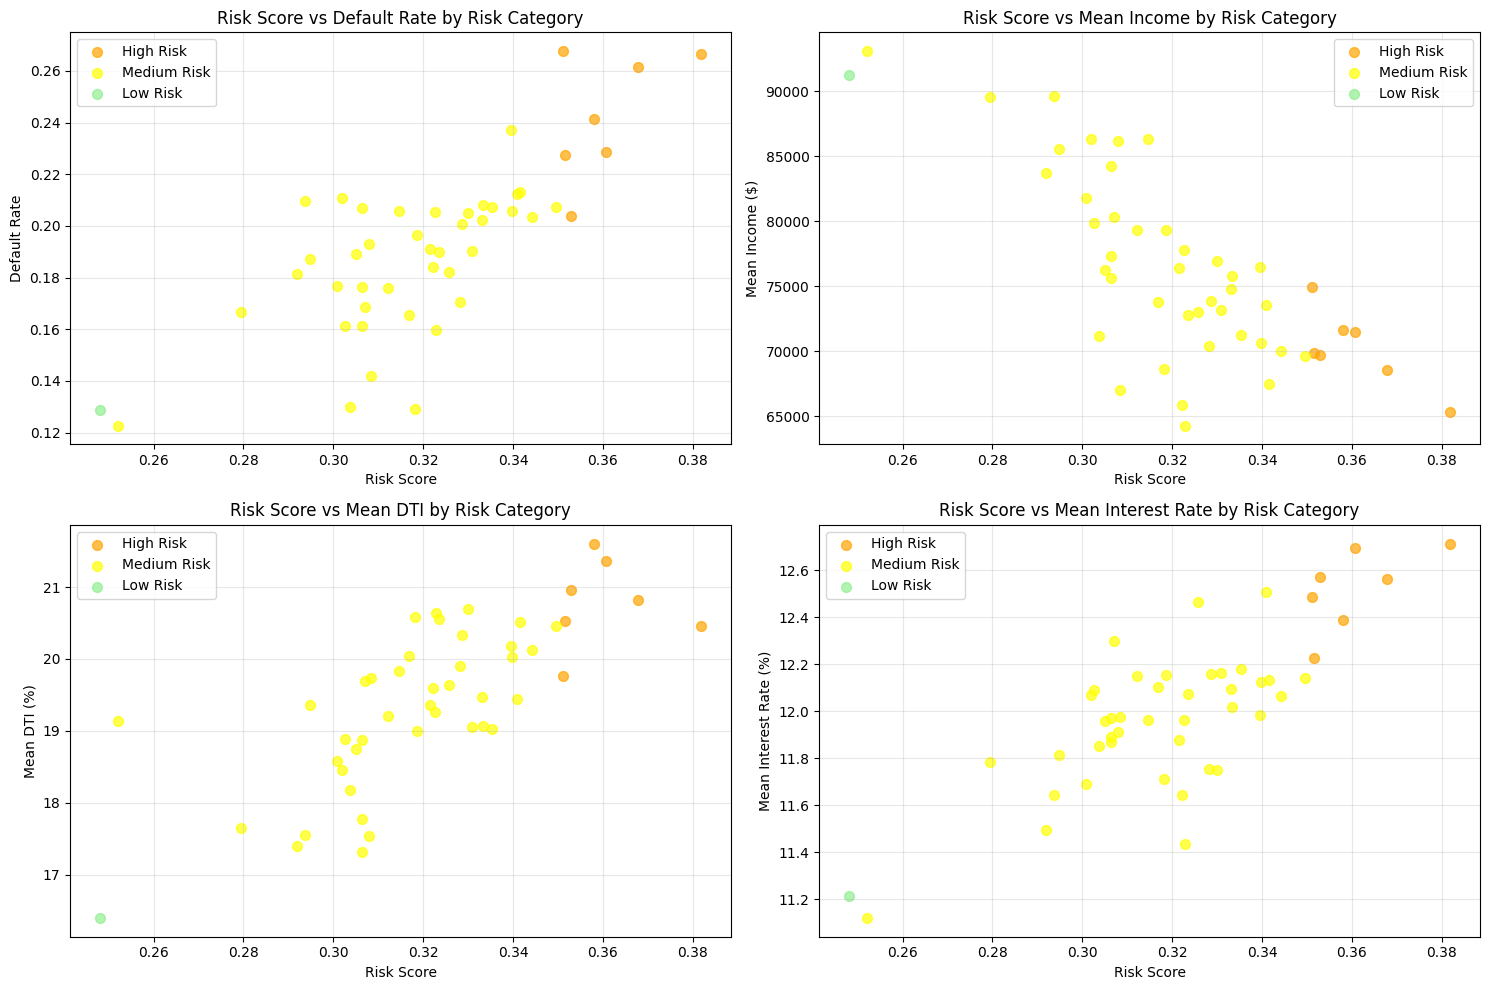

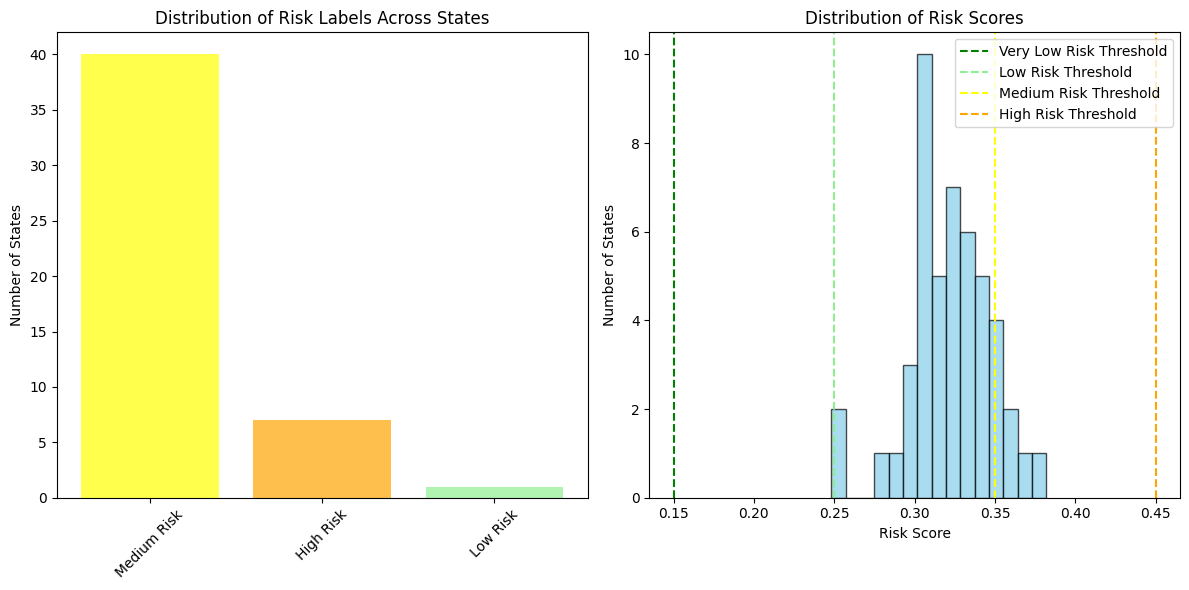

=== IMPLEMENTATION GUIDELINES ===

1. RISK SCORING FORMULA IMPLEMENTATION:
   Risk Score = (Default_Rate × 0.35) + (Income_Score × 0.20) + (DTI_Score × 0.15) + (Interest_Score × 0.15) + (FICO_Score × 0.10) + (Loan_Volume_Score × 0.05)

2. RISK LABEL ASSIGNMENT:
   • Very Low Risk: Risk Score < 0.15
   • Low Risk: Risk Score < 0.25
   • Medium Risk: Risk Score < 0.35
   • High Risk: Risk Score < 0.45
   • Very High Risk: Risk Score ≥ 0.45

3. BUSINESS APPLICATIONS:
   • Loan Pricing: Adjust interest rates based on risk category
   • Underwriting: Apply different approval criteria by risk level
   • Portfolio Management: Set exposure limits by risk category
   • Marketing: Target different customer segments

4. MONITORING AND UPDATES:
   • Update risk scores quarterly with new data
   • Monitor economic indicators for each state
   • Adjust thresholds based on portfolio performance
   • Validate model performance regularly

5. RISK MITIGATION STRATEGIES:
   • Very High Risk: Stricter und

In [43]:
if __name__ == "__main__":
    main()